# Research Question 1: What moth species are the most susceptible to changes in environmental drivers?

## Loading Libraries and Mounting Drive

In [1]:
# mounting drive
from google.colab import drive
drive.mount("/content/drive")

# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import statsmodels.api as sm
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

Mounted at /content/drive


## Loading the Dataset

In [2]:
# loading the dataset
path = "/content/drive/MyDrive/Colab Notebooks/SCC 450 - Group Project/Week 10/Data/DATA_CLEAN.csv"
df = pd.read_csv(path, parse_dates = ["SAMPLE_DATE", "FROMDATE", "SDATE"])


/tmp/ipython-input-2811573798.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, parse_dates = ["SAMPLE_DATE", "FROMDATE", "SDATE"])


## Plot: Top 10 Species (based on count)

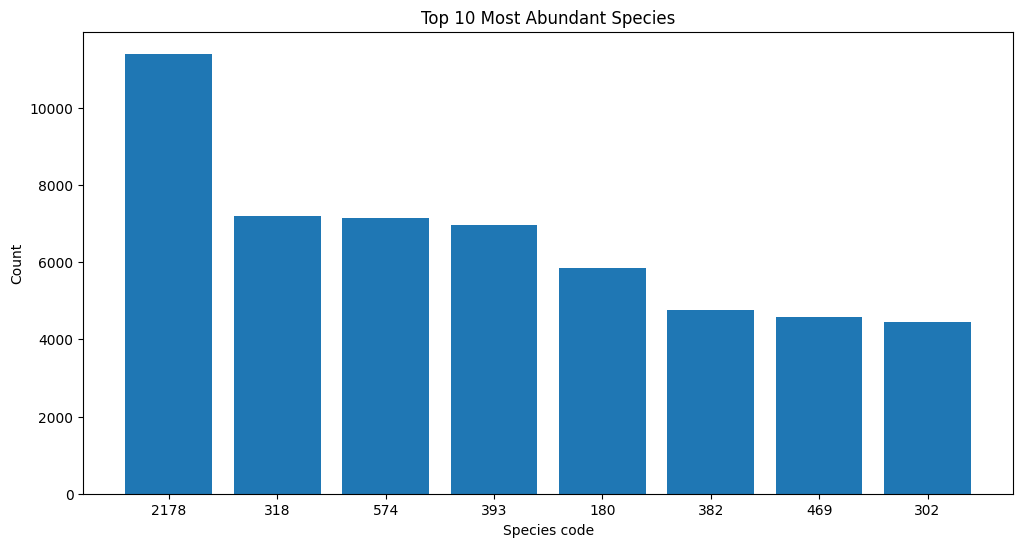

In [3]:
# calculating the top 10 species
top_10 = df[["SITECODE", "YEAR", "LCODE", "SAMPLE_DATE", "VALUE", "FIELDNAME"]].drop_duplicates()
top_10 = top_10[top_10["FIELDNAME"] != "XX"]
top_10 = top_10.groupby('FIELDNAME')["VALUE"].sum().sort_values(ascending = False)


# plotting
plt.figure(figsize = (12, 6))

plt.bar(top_10.iloc[:10].index.astype(str), top_10.iloc[:10].values)
plt.xlabel("Species code")
plt.ylabel("Count")
plt.title("Top 10 Most Abundant Species")
plt.show()

## Plot: Top 10 Species Trend

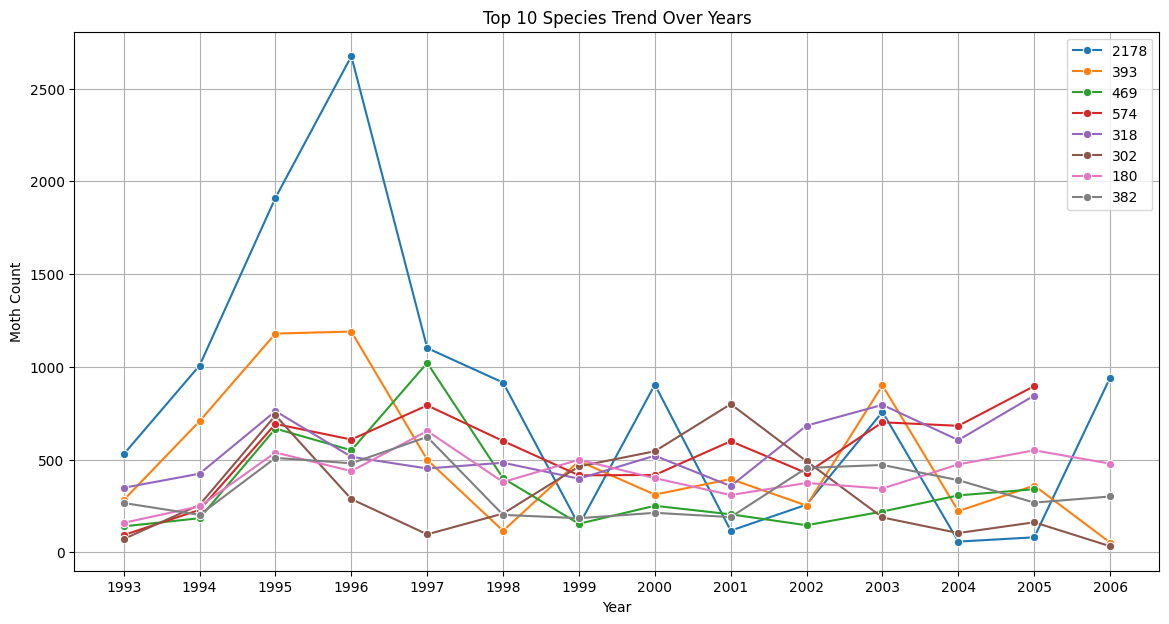

In [4]:
# calculating the top 10 species
top_10 = df[["SITECODE", "YEAR", "LCODE", "SAMPLE_DATE", "VALUE", "FIELDNAME"]].drop_duplicates()
top_10 = top_10[top_10["FIELDNAME"] != "XX"]
top_10 = top_10.groupby(['FIELDNAME', "YEAR"])["VALUE"].sum().sort_values(ascending = False).reset_index()

top_10_species = ["2178", "318", "574", "393", "180", "382", "469", "302"]
top_10 = top_10[top_10["FIELDNAME"].isin(top_10_species)]

# plotting
plt.figure(figsize = (14, 7))
sns.lineplot(x = top_10["YEAR"], y = top_10["VALUE"], hue = top_10["FIELDNAME"], marker = "o")
plt.xlabel("Year")
plt.ylabel("Moth Count")
plt.title("Top 10 Species Trend Over Years")
plt.xticks(top_10["YEAR"].unique())
plt.legend()
plt.grid(True)
plt.show()

## Preparing Data for Modelling

In [5]:
# loading the dataset - without duplicates for moth data and averages of weather data for samples with SPERIOD_D > 1
path = "/content/drive/MyDrive/Colab Notebooks/SCC 450 - Group Project/Week 10/Data/DATA_CLEAN(no_moth_duplicates).csv"
df = pd.read_csv(path, parse_dates = ["SAMPLE_DATE", "FROMDATE"])

# preparing data for modelling - keeping only FIELDNAME, VALUE and weather variables
cols_to_keep =  ["FIELDNAME", "VALUE", "DRYTMP", "NETRAD", "SOLAR", "STMP10", "STMP30", "SURWET", "WSPEED", "RAIN"]
species_model = df.loc[:, cols_to_keep]
species_model = species_model[species_model["FIELDNAME"] != "XX"].reset_index(drop = True)
species_model

# using log scaling to VALUE
species_model["LOG_VALUE"] = np.log(species_model["VALUE"])
species_model = species_model.loc[:, ["FIELDNAME", "VALUE", "LOG_VALUE", "DRYTMP", "NETRAD", "SOLAR", "STMP10", "STMP30", "SURWET", "WSPEED", "RAIN"]]

# scaling weather variables using RobustScaler
robust_scaler = RobustScaler()
cols = ["DRYTMP", "NETRAD", "SOLAR", "STMP10", "STMP30", "SURWET", "WSPEED", "RAIN"]
for col in cols:
  robust_scaler = RobustScaler()
  species_model[col] = robust_scaler.fit_transform(species_model[[col]])

species_model

,FIELDNAME,VALUE,LOG_VALUE,DRYTMP,NETRAD,SOLAR,STMP10,STMP30,SURWET,WSPEED,RAIN
0,828,1,0.000000,-1.351801,-1.195796,-1.404897,-2.115603,-2.487404,0.633135,-0.058633,1.40
1,590,1,0.000000,-1.574273,-1.268859,-1.444312,-1.948368,-2.244601,-0.482381,-0.323608,3.10
2,2542,1,0.000000,-2.217452,-1.342562,-1.471456,-2.699302,-2.092184,0.773561,0.434672,1.70
3,905,1,0.000000,-2.217452,-1.342562,-1.471456,-2.699302,-2.092184,0.773561,0.434672,1.70
4,929,1,0.000000,-2.217452,-1.342562,-1.471456,-2.699302,-2.092184,0.773561,0.434672,1.70
...,...,...,...,...,...,...,...,...,...,...,...
156237,579,1,0.000000,-1.509139,-1.017433,-0.665283,-1.649491,-1.584525,0.127715,5.514105,3.24
156238,769,2,0.693147,-1.509139,-1.017433,-0.665283,-1.649491,-1.584525,0.127715,5.514105,3.24
156239,778,2,0.693147,-1.509139,-1.017433,-0.665283,-1.649491,-1.584525,0.127715,5.514105,3.24
156240,824,4,1.386294,-1.509139,-1.017433,-0.665283,-1.649491,-1.584525,0.127715,5.514105,3.24


### Correlation Heatmap of Weather Variables

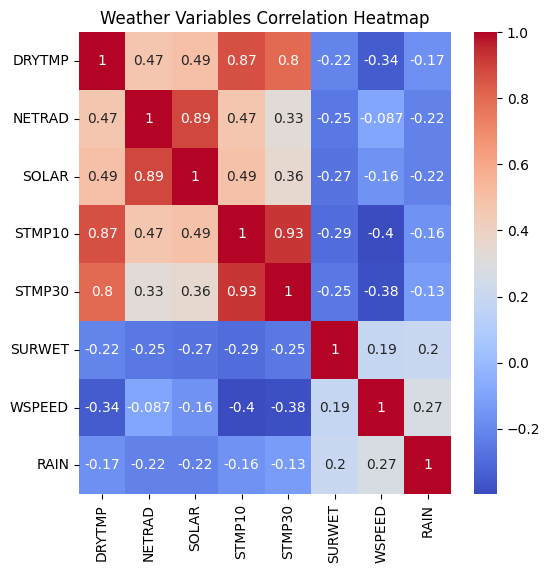

In [6]:
# creating correlation matrix for weather variables
weather_vars = ["DRYTMP", "NETRAD", "SOLAR", "STMP10", "STMP30", "SURWET", "WSPEED", "RAIN"]
weather_corr = species_model[weather_vars].corr()

# plotting
plt.figure(figsize = (6, 6))
sns.heatmap(weather_corr, cmap = "coolwarm", annot = True)
plt.title("Weather Variables Correlation Heatmap")
plt.show()

# high correlation between NETRAD and SOLAR
# high correlation between STMP10 and STMP30 and DRYTMP

## Modelling

In [7]:
# modelling to extract coefficients of signficant drivers for each species - using RidgeCV and OLS regressions due to multicollinearity

# determining weather variables
weather_vars = ["DRYTMP", "NETRAD", "SOLAR", "STMP10", "STMP30", "SURWET", "WSPEED", "RAIN"]

# identifying unique species
all_species = species_model["FIELDNAME"].unique().tolist()

# initializing empty list to which we append results
results = []

# specifying the alphas for testing for L2 regularization
alphas_to_test = np.array([0.1, 1.0, 5.0, 10.0, 20.0, 50.0, 100.0])

# loop for regressiom
for species in all_species:
  # selecting chunk of data for specific species
  data = species_model[species_model["FIELDNAME"] == species]

# checking if the chunk of the data has enough entries (15)
  if data.shape[0] >= 15:
    # determining dependent and indenpendent variables
    X = data[weather_vars]
    Y = data["LOG_VALUE"]

    # performing RidgeCV - calculates L2 regularization (penalty for multicollinearity) based on every species and finds the biggest driver of that species
    ridge_model = RidgeCV(alphas = alphas_to_test, cv = 5).fit(X, Y)

    # determining the biggest weather driver for the species
    largest_driver = np.argmax(np.abs(ridge_model.coef_))
    largest_driver = weather_vars[largest_driver]

    # getting data ready for OLS only using the biggest driver determined by RidgeCV regression
    ols_X = data[largest_driver]
    ols_Y = data["LOG_VALUE"]
    ols_X = sm.add_constant(ols_X)

    # fitting the OLS model
    ols_model = sm.OLS(ols_Y, ols_X)
    result = ols_model.fit()

    # getting specific p_value for the biggest driver determined by the ridge_model
    driver_pvalue = result.pvalues[largest_driver]

    # checking if driver identified by ridge model is significant (p-value < 0.05)
    if driver_pvalue <= 0.05:
      # if yes - appending species ID, driver's name, p-value, coefficient, and r2
      results.append({
          "FIELDNAME": species,
          "MAX_DRIVER": largest_driver,
          "P_VALUE": driver_pvalue,
          "COEFFICIENT": result.params.get(largest_driver),
          "R_SQUARED": result.rsquared
      })

# transforming results into dataframe
results = pd.DataFrame(results)

# sorting the dataframe based on absolute value of the coefficient
results = results.sort_values(by = "COEFFICIENT", key = abs, ascending = False)

# output of results
results

# next sections - using PCA to handle mutlicollinearity more effectively and using linear regression to extract the coefficients for each PCA component

,FIELDNAME,MAX_DRIVER,P_VALUE,COEFFICIENT,R_SQUARED
207,442,STMP30,5.206778e-05,1.045183,0.168869
172,824,STMP30,2.614652e-08,-0.915201,0.289793
188,537,SURWET,5.335567e-03,-0.783942,0.212373
109,191,SURWET,5.573536e-10,-0.637257,0.087415
129,461,SURWET,2.850215e-05,-0.548496,0.111963
...,...,...,...,...,...
103,2503,WSPEED,1.390369e-02,0.035138,0.066807
48,473,WSPEED,1.156984e-04,0.031269,0.028527
131,913,RAIN,8.977937e-05,0.028490,0.234118
190,111,RAIN,1.968307e-03,0.025850,0.193619


### Using PCA




In [8]:
# creating a copy of scaled dataset
pca_df = species_model.copy()

# data already standardised so reusing that
W = species_model[weather_vars]

# Running PCA with 3 components
# assuming they'll  be temp/rad, moisture/wetness/rain, wind?
pca = PCA(n_components=3)
pcs = pca.fit_transform(W)

pca_df[["PC1", "PC2", "PC3"]] = pcs

# calculating variance ratios
print("Explained var ratios: ", pca.explained_variance_ratio_)
pca_df.head()

Explained var ratios:  [0.82612677 0.08920445 0.03772461]


,FIELDNAME,VALUE,LOG_VALUE,DRYTMP,NETRAD,SOLAR,STMP10,STMP30,SURWET,WSPEED,RAIN,PC1,PC2,PC3
0,828,1,0.0,-1.351801,-1.195796,-1.404897,-2.115603,-2.487404,0.633135,-0.058633,1.4,0.125938,-3.381219,-1.500818
1,590,1,0.0,-1.574273,-1.268859,-1.444312,-1.948368,-2.244601,-0.482381,-0.323608,3.1,1.763669,-2.911992,-1.763092
2,2542,1,0.0,-2.217452,-1.342562,-1.471456,-2.699302,-2.092184,0.773561,0.434672,1.7,0.511405,-4.149905,-1.320574
3,905,1,0.0,-2.217452,-1.342562,-1.471456,-2.699302,-2.092184,0.773561,0.434672,1.7,0.511405,-4.149905,-1.320574
4,929,1,0.0,-2.217452,-1.342562,-1.471456,-2.699302,-2.092184,0.773561,0.434672,1.7,0.511405,-4.149905,-1.320574


In [9]:
# seeing how each met variable contributes to each pc
loadings = pd.DataFrame(pca.components_.T, columns=["PC1", "PC2", "PC3"], index=weather_vars)

print("PCA loadings: ")
loadings.style.background_gradient(cmap="coolwarm")

PCA loadings: 


,PC1,PC2,PC3
DRYTMP,-0.036756,0.492207,0.099026
NETRAD,-0.037591,0.270373,0.425446
SOLAR,-0.038525,0.295886,0.380841
STMP10,-0.033260,0.491914,0.045753
STMP30,-0.025758,0.439881,-0.020421
SURWET,0.031243,-0.143190,-0.045159
WSPEED,0.068315,-0.362851,0.811938
RAIN,0.994152,0.097176,-0.018867


### Each species vs PCs
Performing regression to see how each species is against PC1/2/3 components


In [10]:
# performing regression to see how each species is against PC1/2/3 components

pca_results = []

for sp, group in pca_df.groupby("FIELDNAME"):
  if len(group) < 15:
    continue

  # using VALUE as response var n then the PCs as predictors
  y = np.log1p(group["VALUE"])
  X = group[["PC1", "PC2", "PC3"]]
  X = sm.add_constant(X)
  model = sm.OLS(y, X).fit()

  pca_results.append({
      "FIELDNAME": sp,
      "COEF_PC1" : model.params["PC1"],
      "COEF_PC2" : model.params["PC2"],
      "COEF_PC3" : model.params["PC3"],
      "p_PC1" : model.pvalues["PC1"],
      "p_PC2" : model.pvalues["PC2"],
      "p_PC3" : model.pvalues["PC3"],
      "R2" : model.rsquared
    })

# converting results of OLS to dataframe
pca_results = pd.DataFrame(pca_results)

# results
pca_results

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model

,FIELDNAME,COEF_PC1,COEF_PC2,COEF_PC3,p_PC1,p_PC2,p_PC3,R2
0,1001,-1.687615e-02,1.012894e-01,6.614796e-02,0.403197,0.000169,0.116028,0.063813
1,1015,8.934171e-03,2.196959e-02,3.316929e-02,0.183203,0.201703,0.230364,0.022262
2,1024,1.197226e-17,-3.832667e-17,1.512295e-16,0.437110,0.229099,0.057537,-inf
3,106,-1.359352e-02,6.702326e-03,1.584303e-02,0.270438,0.850537,0.733404,0.027369
4,107,-1.132359e-02,2.810554e-02,1.443917e-02,0.449148,0.520832,0.734323,0.034466
...,...,...,...,...,...,...,...,...
417,949,-6.938894e-17,2.498002e-16,-2.220446e-16,0.460862,0.441214,0.634337,-8.017857
418,959,1.004786e-02,8.870415e-03,4.312844e-02,0.162325,0.871877,0.392849,0.128216
419,963,-1.425059e-03,3.437734e-02,3.220490e-02,0.797415,0.013505,0.049714,0.025219
420,964,2.929533e-03,7.273892e-03,-3.634441e-02,0.456735,0.648329,0.078101,0.031213


## Answering RQ1: What species shows strongest response to what environmental driver?

In [11]:
# using linear regression for each species' abundance against PCs
# then can rank them
X_weather = species_model[weather_vars]

pca = PCA(n_components=3)
pcs = pca.fit_transform(X_weather)

pc_df = pd.DataFrame(pcs, columns=["PC1", "PC2", "PC3"])
species_pc = pd.concat([species_model[["FIELDNAME", "VALUE"]], pc_df], axis=1)

sensitivity = []

for sp in species_pc["FIELDNAME"].unique():
  sp_df = species_pc[species_pc["FIELDNAME"] == sp]

  # setting 20 as limit for now
  if len(sp_df) < 20:
    X = sp_df[["PC1", "PC2", "PC3"]]
    y = sp_df["VALUE"]

    model = LinearRegression().fit(X, y)

    sensitivity.append({
        "FIELDNAME": sp,
        "PC1_SENSITIVITY": model.coef_[0],
        "PC2_SENSITIVITY": model.coef_[1],
        "PC3_SENSITIVITY": model.coef_[2],
        "MAX_SENSITIVITY": np.max(np.abs(model.coef_))
    })

# putting results of linear regression to dataframe
sensitivity_df = pd.DataFrame(sensitivity)

# sorting the table based on MAX_SENSITIVITY and rounding
table = sensitivity_df.sort_values(by="MAX_SENSITIVITY", ascending=False).reset_index(drop=True)
table = table.round(3)

# displaying top 15
table.head(15)

,FIELDNAME,PC1_SENSITIVITY,PC2_SENSITIVITY,PC3_SENSITIVITY,MAX_SENSITIVITY
0,2501,0.871,-0.182,2.695,2.695
1,208,0.125,-1.486,0.796,1.486
2,348,0.041,-1.161,-0.735,1.161
3,598,0.029,-0.315,1.039,1.039
4,564,0.259,-0.852,-0.884,0.884
5,2550,-0.010,-0.584,0.684,0.684
6,879,-0.601,0.195,-0.240,0.601
7,155,-0.052,-0.472,-0.529,0.529
8,475,0.000,0.499,0.182,0.499
9,802,0.421,0.373,0.281,0.421


In [12]:
# ouputting results
table.to_csv("RQ1_Most_Sensitive_Species.csv", index=False)